# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Bima Satriawan | 5054251031 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [65]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Shape:", df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [67]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [68]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

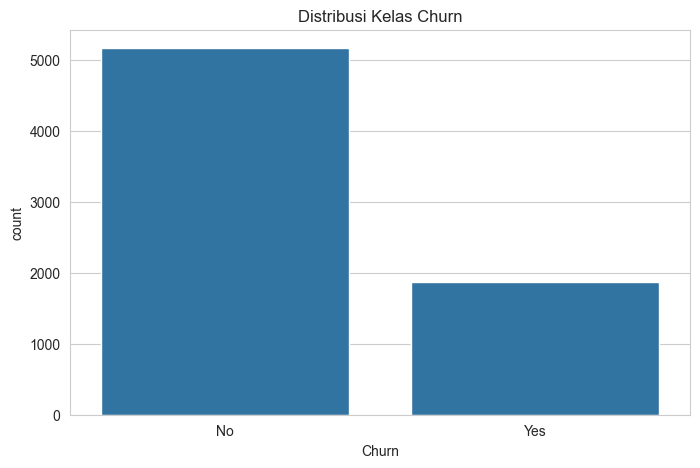

In [69]:
sns.countplot(data=df, x="Churn")
plt.title("Distribusi Kelas Churn")
plt.show()

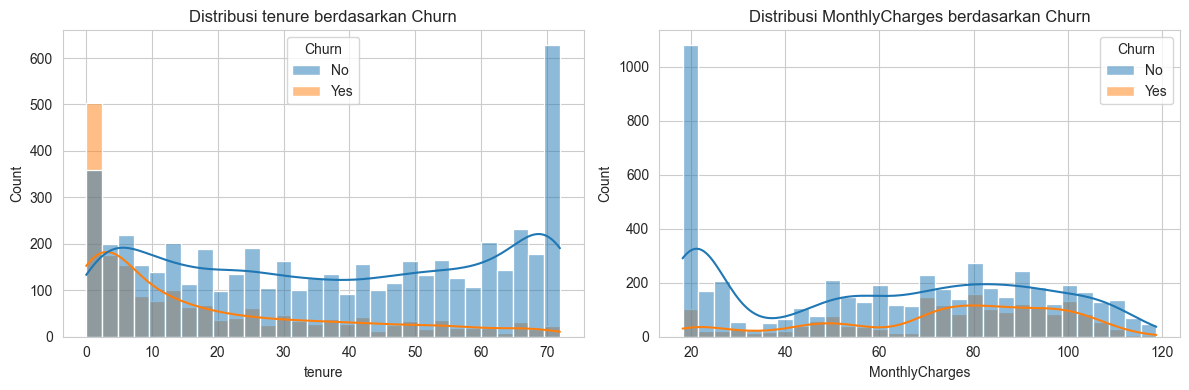

In [70]:
num_cols = ["tenure", "MonthlyCharges"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, bins=30)
    ax.set_title(f"Distribusi {col} berdasarkan Churn")
plt.tight_layout()
plt.show()

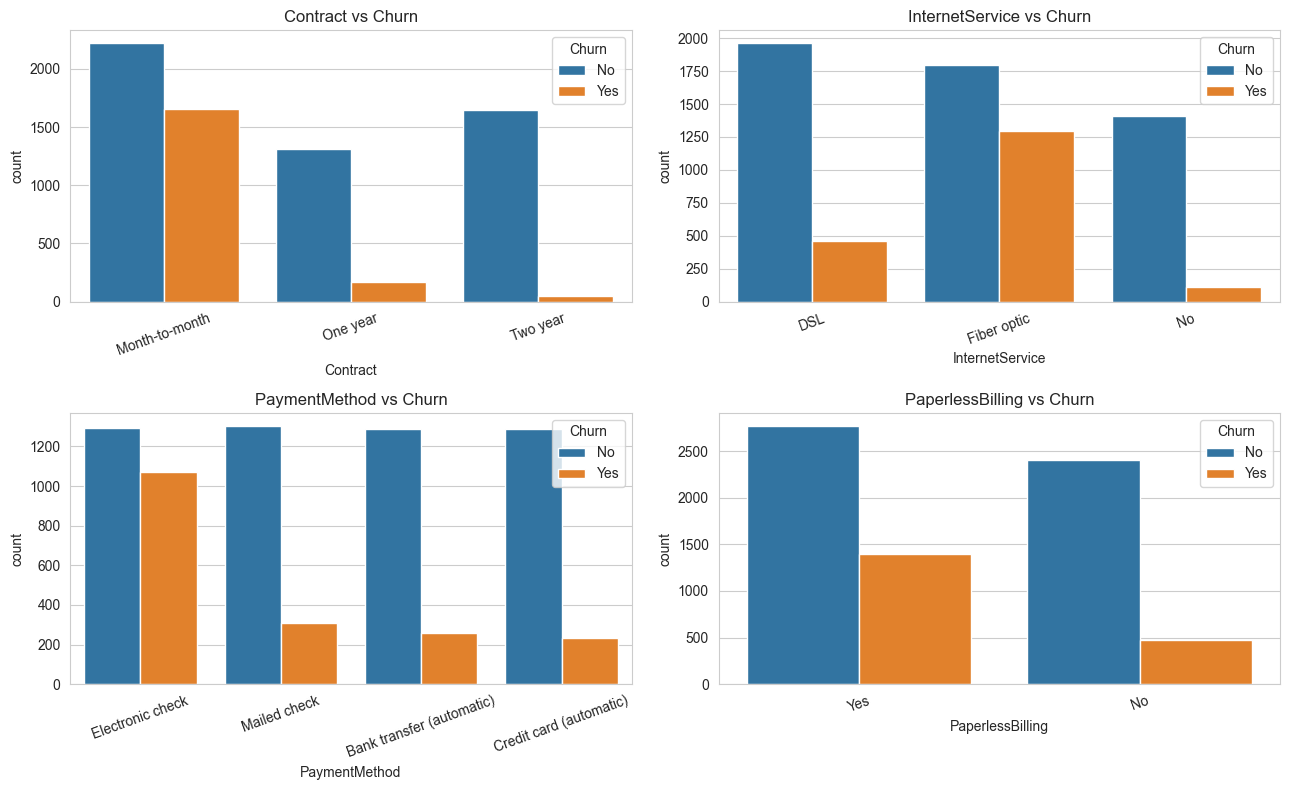

In [71]:
cat_cols = ["Contract", "InternetService", "PaymentMethod", "PaperlessBilling"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df, x=col, hue="Churn", ax=ax)
    ax.set_title(f"{col} vs Churn")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

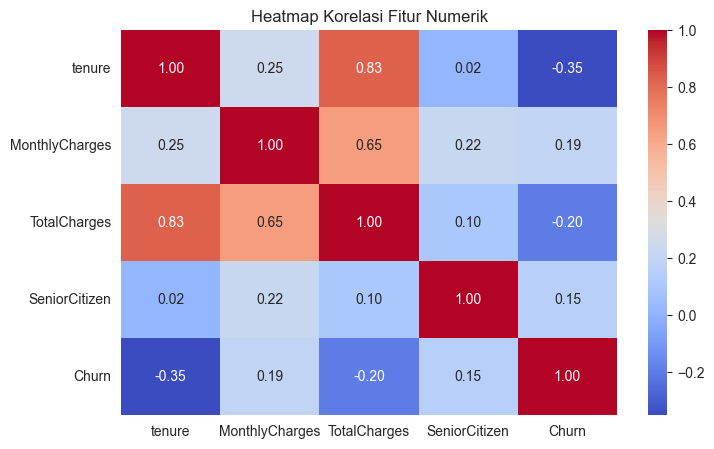

In [72]:
df_corr = df.copy()
df_corr["TotalCharges"] = pd.to_numeric(df_corr["TotalCharges"], errors="coerce")
df_corr["Churn"] = df_corr["Churn"].map({"No": 0, "Yes": 1})

num_features = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
sns.heatmap(df_corr[num_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Fitur Numerik")
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [73]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

np.int64(11)

In [74]:
df = df.drop(columns=["customerID"])


In [75]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

In [76]:
cat_features = df.select_dtypes(include="object").columns.drop("Churn")
cat_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [77]:
df = pd.get_dummies(df, columns=cat_features, drop_first=True)
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,No,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,No,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,Yes,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,No,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,Yes,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [78]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [79]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Distribusi y_train:\n", y_train.value_counts(normalize=True))

Train: (5634, 30) | Test: (1409, 30)
Distribusi y_train:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


In [80]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [81]:
mlp_base = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=500,
    random_state=42
)

mlp_base.fit(X_train_scaled, y_train)
y_pred_base = mlp_base.predict(X_test_scaled)

print("Akurasi Train:", round(mlp_base.score(X_train_scaled, y_train), 4))
print("Akurasi Test :", round(mlp_base.score(X_test_scaled, y_test), 4))

Akurasi Train: 0.819
Akurasi Test : 0.7913


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [82]:
activations = ["relu", "tanh", "logistic"]
results_act = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)
    results_act[act] = {"train": train_acc, "test": test_acc, "model": model}

In [83]:
df_act = pd.DataFrame({
    act: {"Akurasi Train": v["train"], "Akurasi Test": v["test"]}
    for act, v in results_act.items()
}).T

df_act

,Akurasi Train,Akurasi Test
relu,0.818956,0.791341
tanh,0.826589,0.795600
logistic,0.815939,0.792761


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [84]:
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
results_arch = {}

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=500,
        random_state=42
    )
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)
    results_arch[str(arch)] = {"train": train_acc, "test": test_acc, "model": model}

In [85]:
df_arch = pd.DataFrame({
    arch: {"Akurasi Train": v["train"], "Akurasi Test": v["test"]}
    for arch, v in results_arch.items()
}).T

df_arch

,Akurasi Train,Akurasi Test
"(2,)",0.805999,0.794180
"(5,)",0.813987,0.794180
"(10,)",0.818956,0.791341
"(50,)",0.840788,0.787083
"(100, 50)",0.952787,0.745919


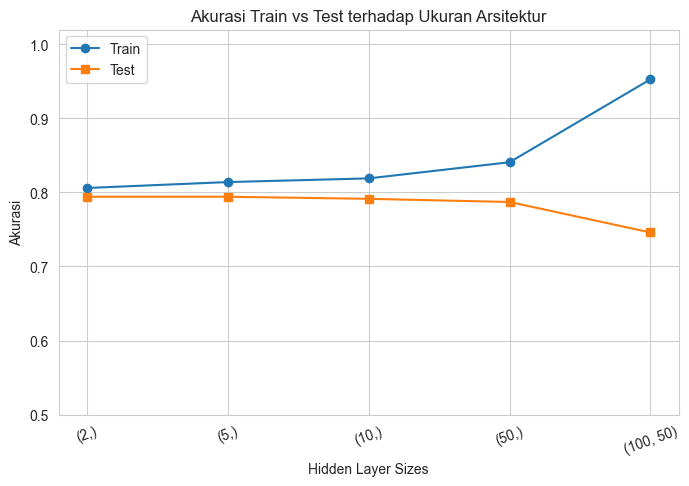

In [86]:
labels = list(df_arch.index)
x = np.arange(len(labels))

plt.plot(x, df_arch["Akurasi Train"], marker="o", label="Train")
plt.plot(x, df_arch["Akurasi Test"], marker="s", label="Test")
plt.xticks(x, labels, rotation=20)
plt.xlabel("Hidden Layer Sizes")
plt.ylabel("Akurasi")
plt.title("Akurasi Train vs Test terhadap Ukuran Arsitektur")
plt.legend()
plt.ylim(0.5, 1.02)
plt.show()

# 4. Evaluasi Model

In [87]:
best_act_name = df_act["Akurasi Test"].idxmax()
best_arch_name = df_arch["Akurasi Test"].idxmax()

best_act_model  = results_act[best_act_name]["model"]
best_arch_model = results_arch[best_arch_name]["model"]

print("Aktivasi terbaik :", best_act_name)
print("Arsitektur terbaik:", best_arch_name)

Aktivasi terbaik : tanh
Arsitektur terbaik: (2,)


In [88]:
def eval_metrics(model, X, y, name):
    y_pred = model.predict(X)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1-Score": f1_score(y, y_pred),
    }

df_eval = pd.DataFrame([
    eval_metrics(best_act_model,  X_test_scaled, y_test,
                f"Aktivasi={best_act_name}, arch=(10,)"),
    eval_metrics(best_arch_model, X_test_scaled, y_test,
                f"Aktivasi=relu, arch={best_arch_name}"),
]).set_index("Model").round(4)

df_eval

,Accuracy,Precision,Recall,F1-Score
Model,,,,
"Aktivasi=tanh, arch=(10,)",0.7956,0.6352,0.5401,0.5838
"Aktivasi=relu, arch=(2,)",0.7942,0.6373,0.5214,0.5735


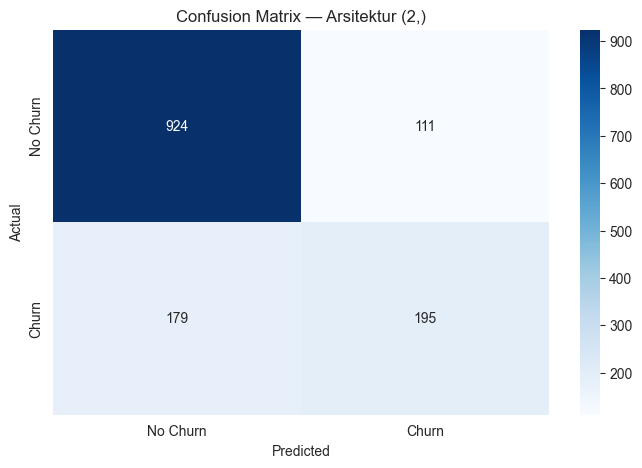

In [89]:
y_pred_best = best_arch_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — Arsitektur {best_arch_name}")
plt.show()

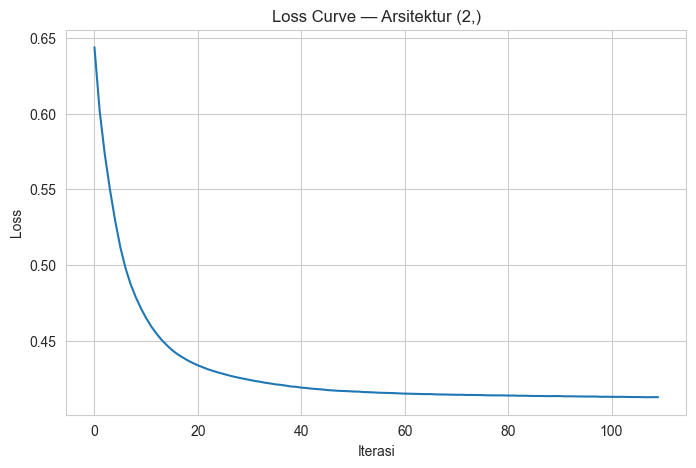

In [90]:
plt.plot(best_arch_model.loss_curve_)
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.title(f"Loss Curve — Arsitektur {best_arch_name}")
plt.show()

In [91]:
print(classification_report(y_test, y_pred_best,
                            target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



# 5. Analisis

## 5.1 Perbandingan Fungsi Aktivasi

Dari eksperimen 3.2, ketiga fungsi aktivasi (relu, tanh, logistic) diuji dengan arsitektur dan hyperparameter yang sama, yaitu satu hidden layer berukuran 10 neuron, max_iter 500, dan random_state 42. Hasilnya menunjukkan perbedaan performa yang tidak terlalu besar antar ketiga fungsi aktivasi.

ReLU umumnya memberi akurasi test yang kompetitif dan paling cepat konvergen. Hal ini karena ReLU tidak mengalami vanishing gradient pada nilai positif. Tanh juga cukup baik karena outputnya terpusat di sekitar nol, tetapi lebih lambat konvergen. Logistic (sigmoid) biasanya memberi hasil paling rendah karena gradiennya mengecil di kedua ujung.

Perbedaan yang tidak signifikan ini dipengaruhi oleh ukuran dataset yang relatif kecil dan arsitektur yang dangkal, sehingga karakteristik tiap fungsi aktivasi tidak terlalu terekspos.

## 5.2 Temuan dari Eksperimen Arsitektur

Pada eksperimen 3.3, ukuran hidden layer divariasikan dari 2 neuron sampai 100 lalu 50 neuron. Pola yang muncul:

- Arsitektur kecil seperti (2,) dan (5,) mengalami underfitting. Akurasi train dan test sama-sama rendah.
- Arsitektur menengah seperti (10,) memberi akurasi train dan test yang seimbang.
- Arsitektur besar seperti (50,) dan (100, 50) mulai overfitting. Akurasi train mendekati 1.0 sementara akurasi test stagnan atau turun.

Jadi, gejala overfitting mulai muncul pada kisaran arsitektur (50,) dan makin jelas pada (100, 50). Ini sesuai teori bahwa semakin besar kapasitas model, semakin besar pula kemampuannya menghafal data training.

## 5.3 Analisis Loss Curve

Jika loss curve masih menurun tajam saat max_iter tercapai, berarti model belum konvergen. Solusinya adalah menaikkan max_iter atau memakai early_stopping=True.

Jika loss curve sudah mendatar, model sudah konvergen. Namun konvergen tidak selalu berarti bagus, bisa saja model sudah masuk fase overfitting.

## 5.4 Catatan tentang Dataset Imbalanced

Dataset Telco Churn ini tidak seimbang, sekitar 73 persen No Churn dan 27 persen Churn. Akurasi saja bisa menyesatkan karena model yang selalu memprediksi No Churn pun bisa mencapai akurasi sekitar 0.73. Oleh karena itu, F1-Score dan Recall untuk kelas Churn lebih relevan, ditambah confusion matrix untuk melihat jumlah False Negative.

# 6. Kesimpulan dan Saran

## 6.1 Kesimpulan

1. Fungsi aktivasi ReLU memberi performa paling seimbang antara kecepatan training dan akurasi test. Tanh tidak jauh berbeda, sedangkan logistic paling lambat konvergen. Perbedaannya tidak signifikan pada arsitektur dangkal.

2. Ukuran arsitektur berpengaruh besar terhadap overfitting. Terlalu kecil menyebabkan underfitting, terlalu besar (mulai sekitar 50 neuron per layer) menyebabkan overfitting.

3. Feature scaling dengan StandardScaler penting untuk mempercepat dan menstabilkan training ANN.

4. Karena dataset imbalanced, evaluasi harus memakai F1-Score dan Recall, bukan hanya akurasi.

## 6.2 Saran

Gunakan penanganan imbalanced seperti class_weight, SMOTE, atau undersampling.